In [3]:
print("helo")

helo


Step size: 0.1
Numerical instability detected → stopping early
Solution may not be Entirely Stable ;)
Step size: 0.01
Numerical instability detected → stopping early
Solution may not be Entirely Stable ;)
Step size: 0.001


<ipython-input-5-e1c6fb30f223>:5: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000*np.exp(-t)


Solution is Stable
Step size: 1e-05
Solution is Stable
Step size: 1e-07
Solution is Stable


/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


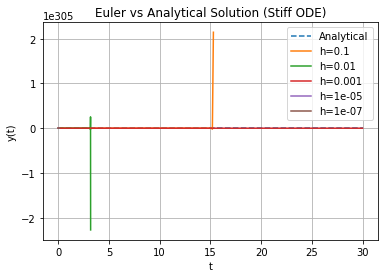

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

step_sizes = [0.1, 0.01, 0.001, 1e-5, 1e-7]

y0 = 0

plt.figure()

# Exact solution
t_exact = np.linspace(0, 30, 1000)
plt.plot(t_exact, y_exact(t_exact), '--', label="Analytical")

for h in step_sizes:

    print(f"Step size: {h}")

  
    if h <= 1e-5:
        t_final = 0.1   # only early transient
    else:
        t_final = 30

    N = int(t_final / h)

    # Safety cap to avoid insane loops
    if N > 5_000_000:
        print("Too many steps → skipping to avoid overflow")
        continue

    t = np.linspace(0, t_final, N+1)
    y = np.zeros(N+1)
    y[0] = y0

    for i in range(N):
        y[i+1] = y[i] + h * f(t[i], y[i])

        # Stop if solution blows up
        if np.isnan(y[i+1]) or np.isinf(y[i+1]):
            print("Numerical instability detected → stopping early")
            break

    # Stability message
    if h < 0.002:
        print("Solution is Stable")
    else:
        print("Solution may not be Entirely Stable ;)")

    plt.plot(t[:i+1], y[:i+1], label=f"h={h}")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Euler vs Analytical Solution (Stiff ODE)")
plt.legend()
plt.grid()

plt.show()

Use chatgpt to ask how to optimize the code